In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from plotly.subplots import make_subplots

# Crossvalidation pour le choix des modèles de classification

## Modèles testés : 
    - Logistic Regression
    - Random Forest
    - XGBoost
    - 
    - 

In [1]:
original_train_dataset = pd.read_csv("conversion_data_train.csv")

NameError: name 'pd' is not defined

# Entrainement des modèles de ML : Version 0 : Dumb models

#### - Modèle 1 : Logistic Regression
#### - Modèle 2 : Random Forest

In [2]:
clean_train_dataset = pd.read_csv("dataset_clean_with_clusters.csv")
original_train_dataset = pd.read_csv("conversion_data_train.csv")

In [3]:
print(len(clean_train_dataset))
print(len(original_train_dataset))

10000
284580


In [4]:
original_train_dataset = original_train_dataset[original_train_dataset["age"]<= 100]
print(len(original_train_dataset))

284578


In [5]:
### 
# Modele numéro 1 : Logistic Regression
###

In [6]:
train_dataset = original_train_dataset.copy()
train_dataset.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [7]:
# split du dataset

In [8]:
X = train_dataset.drop(columns=["converted"])
y = train_dataset["converted"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# preprocessing 

numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source", "new_user"] # new_user est à exclure car déjà un int64 ? 

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [12]:
# params = {"C": 1.0, "solver": "lbfgs", "max_iter": 100}

lr_model = LogisticRegression() # **params)

lr_model.fit(x_train_processed, y_train)
y_pred = lr_model.predict(x_test_processed)

f1 = f1_score(y_test, y_pred)
accuracy = lr_model.score(x_test_processed, y_test)
cm = confusion_matrix(y_test, y_pred)

print(f"F1 Score: {f1}")
# print(f"Accuracy: {accuracy}") Accuracy n'est pas un bon indicateur pour les datasets déséquilibrés. 
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(cm)

F1 Score: 0.7651455546813533
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     82543
           1       0.86      0.69      0.77      2831

    accuracy                           0.99     85374
   macro avg       0.93      0.84      0.88     85374
weighted avg       0.99      0.99      0.99     85374

Confusion Matrix:
[[82235   308]
 [  886  1945]]


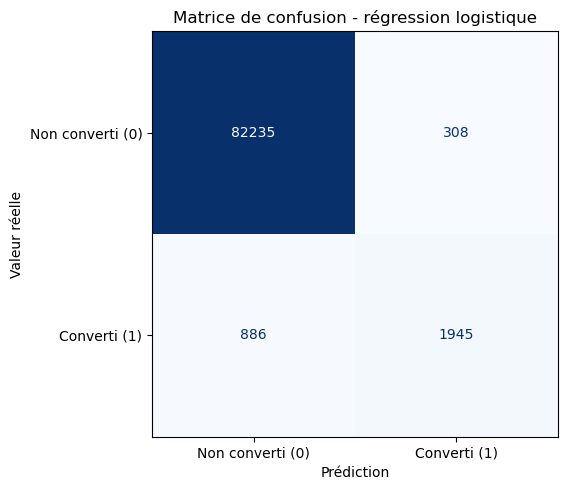

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

ax.set_title("Matrice de confusion - régression logistique")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Valeur réelle")
plt.tight_layout()
plt.show()

In [14]:
###
# modele numéro 2 : Random Forest Classifier
###

In [15]:
rf_model = RandomForestClassifier()

rf_model.fit(x_train_processed, y_train)
y_pred_rf = rf_model.predict(x_test_processed)

f1_rf = f1_score(y_test, y_pred_rf)
accuracy_rf = rf_model.score(x_test_processed, y_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"F1 Score (Random Forest): {f1_rf}")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix (Random Forest):")
print(cm_rf)

F1 Score (Random Forest): 0.7353738860906626
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     82543
           1       0.81      0.67      0.74      2831

    accuracy                           0.98     85374
   macro avg       0.90      0.83      0.86     85374
weighted avg       0.98      0.98      0.98     85374

Confusion Matrix (Random Forest):
[[82110   433]
 [  933  1898]]


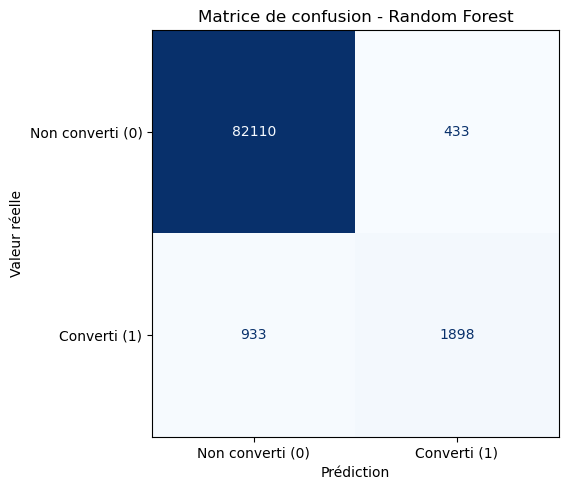

In [16]:
cm_rf= confusion_matrix(y_test, y_pred_rf, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)

ax.set_title("Matrice de confusion - Random Forest")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Valeur réelle")
plt.tight_layout()
plt.show()

### Comparaison des performances des modèles deux modèles : 

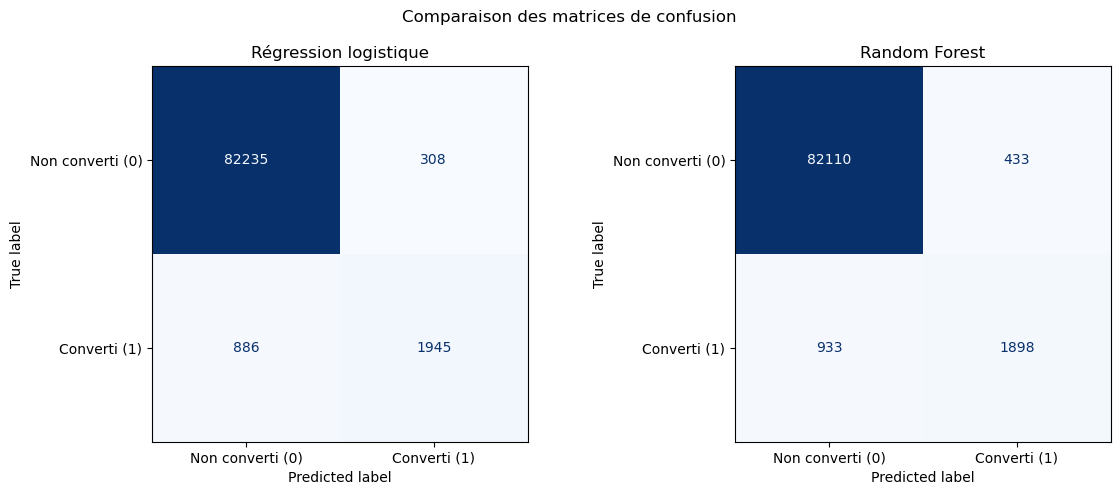

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp_lr.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Régression logistique")

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non converti (0)", "Converti (1)"]
)
disp_rf.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Random Forest")

# Même échelle de couleurs pour faciliter la comparaison
vmax = max(cm.max(), cm_rf.max())
disp_lr.im_.set_clim(0, vmax)
disp_rf.im_.set_clim(0, vmax)

fig.suptitle("Comparaison des matrices de confusion")
plt.tight_layout()
plt.show()

#### =>> En version dumb model, le modèle le plus performant est le modèle Logistic Regression :  
- Le modèle de Logistic regression affiche un F1 score de 0.764 et un recall de 0.69. 
- Le modèle Random Forest affiche un F1 score de 0.734 et un recall de 0.67. 

# To do : faire la cross validation des entrainements des modèles Logistic Regression et Random Forest afin de trouver les meilleurs hyperparamètres pour chaque modèle.

In [18]:
from sklearn.model_selection import StratifiedKFold

# Le choix de StratifiedKFold est pertinent ici car il permet de maintenir la proportion des classes dans chaque fold, 
# ce qui est crucial pour les problèmes de classification déséquilibrée comme celui-ci. 
cv = StratifiedKFold( 
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [19]:
#preprocessing logistic regression 

numeric_features = ["age", "total_pages_visited"]
categorical_features = ["country", "source", "new_user"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [20]:
# x_train_processed = preprocessor.fit_transform(x_train)
# x_test_processed = preprocessor.transform(x_test)

In [21]:
params_lr_lasso = {
    "model__penalty": ["l1"],
    "model__C": [0.01, 0.1, 1, 10, 100], 
    "model__class_weight": [
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5},
    ],
    "model__solver": ["liblinear", "saga"],
    "model__max_iter": [1000, 3000, 5000],
}

params_lr_ridge = {
    "model__penalty": ["l2"],
    "model__C": [0.01, 0.1, 1, 10, 100], 
    "model__class_weight": [
            "balanced",
            {0: 1, 1: 1.5},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
        ],
    "model__solver": ["lbfgs", "liblinear", "saga"],
    "model__max_iter": [1000, 3000],
}

params_lr_elasticnet = {
    "model__penalty": ["elasticnet"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [
            "balanced",
            {0: 1, 1: 1.5},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5},
        ],
    "model__solver": ["saga"],
    "model__l1_ratio": [0.1, 0.5, 0.7, 0.9],
    "model__max_iter": [10000],
}

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = LogisticRegression(
    tol=1e-4,
    random_state=42
)

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),
])

scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "pr_auc": "average_precision",
}

In [23]:
import os

print(os.cpu_count())

8


In [24]:
grid_lr_lasso = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=params_lr_lasso,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1
)
grid_lr_lasso.fit(x_train, y_train)

grid_lr_ridge = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=params_lr_ridge,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1
)
grid_lr_ridge.fit(x_train, y_train)

grid_lr_elasticnet = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=params_lr_elasticnet,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1
)
grid_lr_elasticnet.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'total_pages_visited']),
                                                                        ('cat',
                                                                         OneHotEncoder(),
                                                                         ['country',
                                                                          'source',
                                                                          'new_user'])])),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__class_weight': ['balanced', {0: 1, 1: 1.5},
                                                 {0: 1, 1: 2}, {0: 1, 1: 3},
                                                 {0: 1, 1: 5}],
                         'model__l1_ratio': [0.1, 0.5, 0.7, 0.9],
                         'model__max_iter': [10000],
                         'model__penalty': ['elasticnet'],
                         'model__solver': ['saga']},
             refit='f1',
             scoring={'f1': 'f1', 'pr_auc': 'average_precision',
                      'precision': 'precision', 'recall': 'recall'})

In [25]:
results_elasticnet = pd.DataFrame(grid_lr_elasticnet.cv_results_)
display(results_elasticnet.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__l1_ratio,param_model__max_iter,param_model__penalty,param_model__solver,...,std_test_precision,rank_test_precision,split0_test_pr_auc,split1_test_pr_auc,split2_test_pr_auc,split3_test_pr_auc,split4_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
0,1.844597,0.147432,0.092480,0.014475,0.01,balanced,0.1,10000,elasticnet,saga,...,0.008170,82,0.834330,0.839750,0.837823,0.851975,0.837544,0.840284,0.006099,81
1,1.688917,0.154864,0.098467,0.014337,0.01,balanced,0.5,10000,elasticnet,saga,...,0.007665,81,0.834163,0.839772,0.837796,0.852072,0.837539,0.840269,0.006171,82
2,1.740699,0.155158,0.110964,0.014019,0.01,balanced,0.7,10000,elasticnet,saga,...,0.007577,83,0.834007,0.839768,0.837792,0.852056,0.837486,0.840222,0.006201,83
3,6.305148,0.031327,0.127026,0.032356,0.01,balanced,0.9,10000,elasticnet,saga,...,0.007878,100,0.833744,0.839730,0.837822,0.852025,0.837365,0.840137,0.006251,84
4,2.383461,1.032560,0.151671,0.080085,0.01,"{0: 1, 1: 1.5}",0.1,10000,elasticnet,saga,...,0.011578,1,0.833305,0.838086,0.836711,0.849667,0.834873,0.838528,0.005800,97
5,1.869927,0.674739,0.084645,0.013493,0.01,"{0: 1, 1: 1.5}",0.5,10000,elasticnet,saga,...,0.010510,2,0.832878,0.837953,0.836564,0.849497,0.834499,0.838278,0.005871,98
6,1.904254,0.223830,0.154236,0.064364,0.01,"{0: 1, 1: 1.5}",0.7,10000,elasticnet,saga,...,0.011331,3,0.832631,0.837819,0.836488,0.849379,0.834286,0.838120,0.005905,99
7,4.516326,0.080227,0.105393,0.013218,0.01,"{0: 1, 1: 1.5}",0.9,10000,elasticnet,saga,...,0.011402,4,0.832117,0.837620,0.836268,0.849508,0.834171,0.837937,0.006080,100
8,1.470924,0.047770,0.077862,0.007106,0.01,"{0: 1, 1: 2}",0.1,10000,elasticnet,saga,...,0.011224,21,0.833626,0.838498,0.837078,0.850185,0.835501,0.838978,0.005834,93
9,1.470000,0.068220,0.088550,0.003929,0.01,"{0: 1, 1: 2}",0.5,10000,elasticnet,saga,...,0.012479,22,0.833384,0.838438,0.837002,0.850206,0.835331,0.838872,0.005913,94


In [26]:
results_lasso = pd.DataFrame(grid_lr_lasso.cv_results_)
display(results_lasso.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__max_iter,param_model__penalty,param_model__solver,params,...,std_test_precision,rank_test_precision,split0_test_pr_auc,split1_test_pr_auc,split2_test_pr_auc,split3_test_pr_auc,split4_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
0,1.626251,0.097835,0.215865,0.075133,0.01,balanced,1000,l1,liblinear,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007331,148,0.833944,0.839750,0.837727,0.852046,0.837581,0.840210,0.006207,121
1,2.847952,0.564933,0.105736,0.007642,0.01,balanced,1000,l1,saga,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007964,145,0.833640,0.839683,0.837841,0.851968,0.837346,0.840096,0.006252,127
2,0.844511,0.068461,0.112512,0.031085,0.01,balanced,3000,l1,liblinear,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007331,148,0.833944,0.839750,0.837727,0.852046,0.837581,0.840210,0.006207,121
3,2.094407,0.233090,0.094689,0.003605,0.01,balanced,3000,l1,saga,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007964,145,0.833640,0.839683,0.837841,0.851968,0.837346,0.840096,0.006252,127
4,0.774886,0.054874,0.096906,0.013330,0.01,balanced,5000,l1,liblinear,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007331,148,0.833944,0.839750,0.837727,0.852046,0.837581,0.840210,0.006207,121
5,2.113088,0.203844,0.096159,0.028057,0.01,balanced,5000,l1,saga,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007964,145,0.833640,0.839683,0.837841,0.851968,0.837346,0.840096,0.006252,127
6,0.807895,0.056274,0.092584,0.021312,0.01,"{0: 1, 1: 1.5}",1000,l1,liblinear,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.011723,1,0.833593,0.838755,0.837244,0.850499,0.835232,0.839065,0.005979,142
7,1.589191,0.092509,0.091926,0.010646,0.01,"{0: 1, 1: 1.5}",1000,l1,saga,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.010161,4,0.832097,0.837683,0.836231,0.849552,0.834132,0.837939,0.006107,148
8,0.885656,0.043344,0.085545,0.012811,0.01,"{0: 1, 1: 1.5}",3000,l1,liblinear,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.011723,1,0.833593,0.838755,0.837244,0.850499,0.835232,0.839065,0.005979,142
9,1.596285,0.104890,0.089170,0.013549,0.01,"{0: 1, 1: 1.5}",3000,l1,saga,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.010161,4,0.832097,0.837683,0.836231,0.849552,0.834132,0.837939,0.006107,148


In [27]:
results_ridge = pd.DataFrame(grid_lr_ridge.cv_results_)
display(results_ridge.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,param_model__max_iter,param_model__penalty,param_model__solver,params,...,std_test_precision,rank_test_precision,split0_test_pr_auc,split1_test_pr_auc,split2_test_pr_auc,split3_test_pr_auc,split4_test_pr_auc,mean_test_pr_auc,std_test_pr_auc,rank_test_pr_auc
0,0.779455,0.038920,0.110386,0.013022,0.01,balanced,1000,l2,lbfgs,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007837,121,0.834304,0.839748,0.837835,0.851953,0.837532,0.840274,0.006096,125
1,0.459424,0.019135,0.117717,0.007738,0.01,balanced,1000,l2,liblinear,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007737,149,0.834467,0.839814,0.837747,0.852078,0.837450,0.840311,0.006126,121
2,1.628427,0.099933,0.111078,0.008944,0.01,balanced,1000,l2,saga,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007808,123,0.834315,0.839750,0.837837,0.851944,0.837531,0.840275,0.006090,123
3,0.474200,0.034160,0.097458,0.006400,0.01,balanced,3000,l2,lbfgs,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007837,121,0.834304,0.839748,0.837835,0.851953,0.837532,0.840274,0.006096,125
4,0.406558,0.015791,0.103709,0.032807,0.01,balanced,3000,l2,liblinear,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007737,149,0.834467,0.839814,0.837747,0.852078,0.837450,0.840311,0.006126,121
5,1.698108,0.074993,0.102825,0.009068,0.01,balanced,3000,l2,saga,"{'model__C': 0.01, 'model__class_weight': 'bal...",...,0.007808,123,0.834315,0.839750,0.837837,0.851944,0.837531,0.840275,0.006090,123
6,0.369887,0.020275,0.103948,0.019072,0.01,"{0: 1, 1: 1.5}",1000,l2,lbfgs,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.012788,3,0.833407,0.838241,0.836808,0.849875,0.834929,0.838652,0.005846,145
7,0.372273,0.025501,0.095259,0.010645,0.01,"{0: 1, 1: 1.5}",1000,l2,liblinear,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.013312,1,0.833751,0.838020,0.836414,0.849605,0.834510,0.838460,0.005768,149
8,1.186056,0.106748,0.123390,0.012053,0.01,"{0: 1, 1: 1.5}",1000,l2,saga,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.011985,5,0.833376,0.838119,0.836738,0.849720,0.834913,0.838573,0.005801,147
9,0.319969,0.028279,0.095896,0.012204,0.01,"{0: 1, 1: 1.5}",3000,l2,lbfgs,"{'model__C': 0.01, 'model__class_weight': {0: ...",...,0.012788,3,0.833407,0.838241,0.836808,0.849875,0.834929,0.838652,0.005846,145


In [28]:
print(f"scores for Logistic Regression with Lasso (L1): {grid_lr_lasso.cv_results_}")
print(f"Best parameters for Logistic Regression with Lasso (L1): {grid_lr_lasso.best_params_}")
print()
print(f"scores for Logistic Regression with Ridge (L2): {grid_lr_ridge.cv_results_}")
print(f"Best parameters for Logistic Regression with Ridge (L2): {grid_lr_ridge.best_params_}")
print()
print(f"scores for Logistic Regression with ElasticNet: {grid_lr_elasticnet.cv_results_}")
print(f"Best parameters for Logistic Regression with ElasticNet: {grid_lr_elasticnet.best_params_}")

scores for Logistic Regression with Lasso (L1): {'mean_fit_time': array([  1.62625103,   2.84795189,   0.84451089,   2.09440732,
         0.77488604,   2.11308804,   0.80789537,   1.58919134,
         0.88565612,   1.59628496,   0.86485009,   1.44642801,
         0.85729594,   1.66066794,   0.96030459,   1.82570639,
         0.86149631,   1.99669018,   1.09158273,   2.120538  ,
         1.01352477,   1.96082902,   0.98872657,   2.04805117,
         1.07221169,   2.35941901,   1.32959256,   2.36406751,
         1.21563582,   2.36773119,   7.7867588 ,   4.6391448 ,
         8.6782383 ,   3.68866091,   6.64057026,   3.50480123,
         7.57493749,   2.88394675,   9.21507816,   3.39444065,
         7.09015517,   2.22820425,   9.11217742,   3.38358974,
        13.10842185,   4.52835112,   9.08592205,   2.39626298,
        10.88344755,   3.78613262,   8.22668982,   2.26429186,
         8.31040726,   2.36730318,  10.67865119,   2.75247822,
        10.16102843,   2.4409451 ,  13.2836678 ,   3

In [29]:
def summarize_grid(grid, model_name):
    results = pd.DataFrame(grid.cv_results_)

    columns = [
        "param_model__C",
        "param_model__class_weight",
        "param_model__solver",
        "param_model__max_iter",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_recall",
        "mean_test_precision",
        "mean_test_pr_auc",
        "rank_test_f1",
    ]

    # Certaines colonnes n'existent pas pour tous les modèles
    columns = [column for column in columns if column in results.columns]

    print(f"\n===== {model_name} =====")
    print("Meilleurs paramètres :")
    print(grid.best_params_)
    print(f"Meilleur F1 moyen : {grid.best_score_:.4f}")

    return results[columns].sort_values("rank_test_f1")


results_lasso = summarize_grid(grid_lr_lasso, "Lasso")
results_ridge = summarize_grid(grid_lr_ridge, "Ridge")
results_elasticnet = summarize_grid(grid_lr_elasticnet, "ElasticNet")

display(results_lasso.head(10))
display(results_ridge.head(10))
display(results_elasticnet.head(10))


===== Lasso =====
Meilleurs paramètres :
{'model__C': 0.01, 'model__class_weight': {0: 1, 1: 1.5}, 'model__max_iter': 1000, 'model__penalty': 'l1', 'model__solver': 'saga'}
Meilleur F1 moyen : 0.7675

===== Ridge =====
Meilleurs paramètres :
{'model__C': 0.1, 'model__class_weight': {0: 1, 1: 1.5}, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Meilleur F1 moyen : 0.7679

===== ElasticNet =====
Meilleurs paramètres :
{'model__C': 0.1, 'model__class_weight': {0: 1, 1: 1.5}, 'model__l1_ratio': 0.1, 'model__max_iter': 10000, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Meilleur F1 moyen : 0.7678


,param_model__C,param_model__class_weight,param_model__solver,param_model__max_iter,mean_test_f1,std_test_f1,mean_test_recall,mean_test_precision,mean_test_pr_auc,rank_test_f1
7,0.01,"{0: 1, 1: 1.5}",saga,1000,0.767542,0.007233,0.720022,0.821911,0.837939,1
9,0.01,"{0: 1, 1: 1.5}",saga,3000,0.767542,0.007233,0.720022,0.821911,0.837939,1
11,0.01,"{0: 1, 1: 1.5}",saga,5000,0.767542,0.007233,0.720022,0.821911,0.837939,1
101,10.00,"{0: 1, 1: 1.5}",saga,5000,0.767389,0.008738,0.729633,0.809429,0.840441,4
128,100.00,"{0: 1, 1: 1.5}",liblinear,3000,0.767389,0.008738,0.729633,0.809429,0.840441,4
129,100.00,"{0: 1, 1: 1.5}",saga,3000,0.767389,0.008738,0.729633,0.809429,0.840442,4
131,100.00,"{0: 1, 1: 1.5}",saga,5000,0.767389,0.008738,0.729633,0.809429,0.840442,4
96,10.00,"{0: 1, 1: 1.5}",liblinear,1000,0.767389,0.008738,0.729633,0.809429,0.840445,4
97,10.00,"{0: 1, 1: 1.5}",saga,1000,0.767389,0.008738,0.729633,0.809429,0.840441,4
98,10.00,"{0: 1, 1: 1.5}",liblinear,3000,0.767389,0.008738,0.729633,0.809429,0.840445,4


,param_model__C,param_model__class_weight,param_model__solver,param_model__max_iter,mean_test_f1,std_test_f1,mean_test_recall,mean_test_precision,mean_test_pr_auc,rank_test_f1
40,0.1,"{0: 1, 1: 1.5}",liblinear,3000,0.767926,0.009457,0.727742,0.813005,0.840388,1
37,0.1,"{0: 1, 1: 1.5}",liblinear,1000,0.767926,0.009457,0.727742,0.813005,0.840388,1
41,0.1,"{0: 1, 1: 1.5}",saga,3000,0.767719,0.009101,0.727900,0.812286,0.840419,3
38,0.1,"{0: 1, 1: 1.5}",saga,1000,0.767719,0.009101,0.727900,0.812286,0.840419,3
36,0.1,"{0: 1, 1: 1.5}",lbfgs,1000,0.767474,0.009434,0.727427,0.812300,0.840386,5
39,0.1,"{0: 1, 1: 1.5}",lbfgs,3000,0.767474,0.009434,0.727427,0.812300,0.840386,5
130,100.0,"{0: 1, 1: 1.5}",liblinear,3000,0.767389,0.008738,0.729633,0.809429,0.840443,7
128,100.0,"{0: 1, 1: 1.5}",saga,1000,0.767389,0.008738,0.729633,0.809429,0.840440,7
97,10.0,"{0: 1, 1: 1.5}",liblinear,1000,0.767389,0.008738,0.729633,0.809429,0.840444,7
98,10.0,"{0: 1, 1: 1.5}",saga,1000,0.767389,0.008738,0.729633,0.809429,0.840441,7


,param_model__C,param_model__class_weight,param_model__solver,param_model__max_iter,mean_test_f1,std_test_f1,mean_test_recall,mean_test_precision,mean_test_pr_auc,rank_test_f1
24,0.10,"{0: 1, 1: 1.5}",saga,10000,0.767759,0.009054,0.728058,0.812187,0.840426,1
7,0.01,"{0: 1, 1: 1.5}",saga,10000,0.767703,0.007444,0.719864,0.822508,0.837937,2
87,100.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840442,3
86,100.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840442,3
64,10.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840441,3
65,10.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840441,3
66,10.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840441,3
67,10.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840441,3
84,100.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840440,3
85,100.00,"{0: 1, 1: 1.5}",saga,10000,0.767389,0.008738,0.729633,0.809429,0.840442,3


In [30]:
model_scores = pd.DataFrame({
    "model": ["Lasso", "Ridge", "ElasticNet"],
    "mean_cv_f1": [
        grid_lr_lasso.best_score_,
        grid_lr_ridge.best_score_,
        grid_lr_elasticnet.best_score_,
    ],
})

display(model_scores.sort_values("mean_cv_f1", ascending=False))

grids = {
    "Lasso": grid_lr_lasso,
    "Ridge": grid_lr_ridge,
    "ElasticNet": grid_lr_elasticnet,
}

best_model_name = max(
    grids,
    key=lambda name: grids[name].best_score_
)

best_grid = grids[best_model_name]
best_model = best_grid.best_estimator_

print(f"Modèle sélectionné : {best_model_name}")
print(f"F1 moyen en validation croisée : {best_grid.best_score_:.4f}")
print(f"Meilleurs paramètres : {best_grid.best_params_}")

,model,mean_cv_f1
1,Ridge,0.767926
2,ElasticNet,0.767759
0,Lasso,0.767542


Modèle sélectionné : Ridge
F1 moyen en validation croisée : 0.7679
Meilleurs paramètres : {'model__C': 0.1, 'model__class_weight': {0: 1, 1: 1.5}, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'liblinear'}


#### Les hyperparamètres à tester pour le modèle de régression logistique sont les suivants :
- La pondération des features explicatives (class_weight) : Le nombre de pages visitées, le pays d'origine et l'âge sont des variables explicatives avec un impact différent sur la conversion. Il faudra donc tester différents poids pour ces features afin de trouver la meilleure combinaison pour le modèle de régression logistique. vu lors de l'EDA.